Data Preparation Complete. Cleaned file saved as 'HealthConnect_Appointment_Data_Cleaned.csv'.

--- KPI CALCULATIONS ---
KPI 1: Overall No-Show Rate: 48.46%
KPI 2: Reminder Attendance Uplift: +4.95% (Sent: 47.63% vs Not Sent: 42.68%)
KPI 3: Avg Lead Time (Attended vs No-Show): 24.52 days vs 34.53 days
KPI 4: High Wait-Time (>30 min) No-Show Rate: 47.67%


C:\Users\Brian\AppData\Local\Temp\ipykernel_15168\3359378367.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='appointment_outcome', palette=['#10b981', '#ef4444', '#f59e0b'], ax=axes[0, 0])
C:\Users\Brian\AppData\Local\Temp\ipykernel_15168\3359378367.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='reminder_channel', y='is_noshow', palette='Blues_r', errorbar=None, ax=axes[0, 1])
C:\Users\Brian\AppData\Local\Temp\ipykernel_15168\3359378367.py:93: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='appo

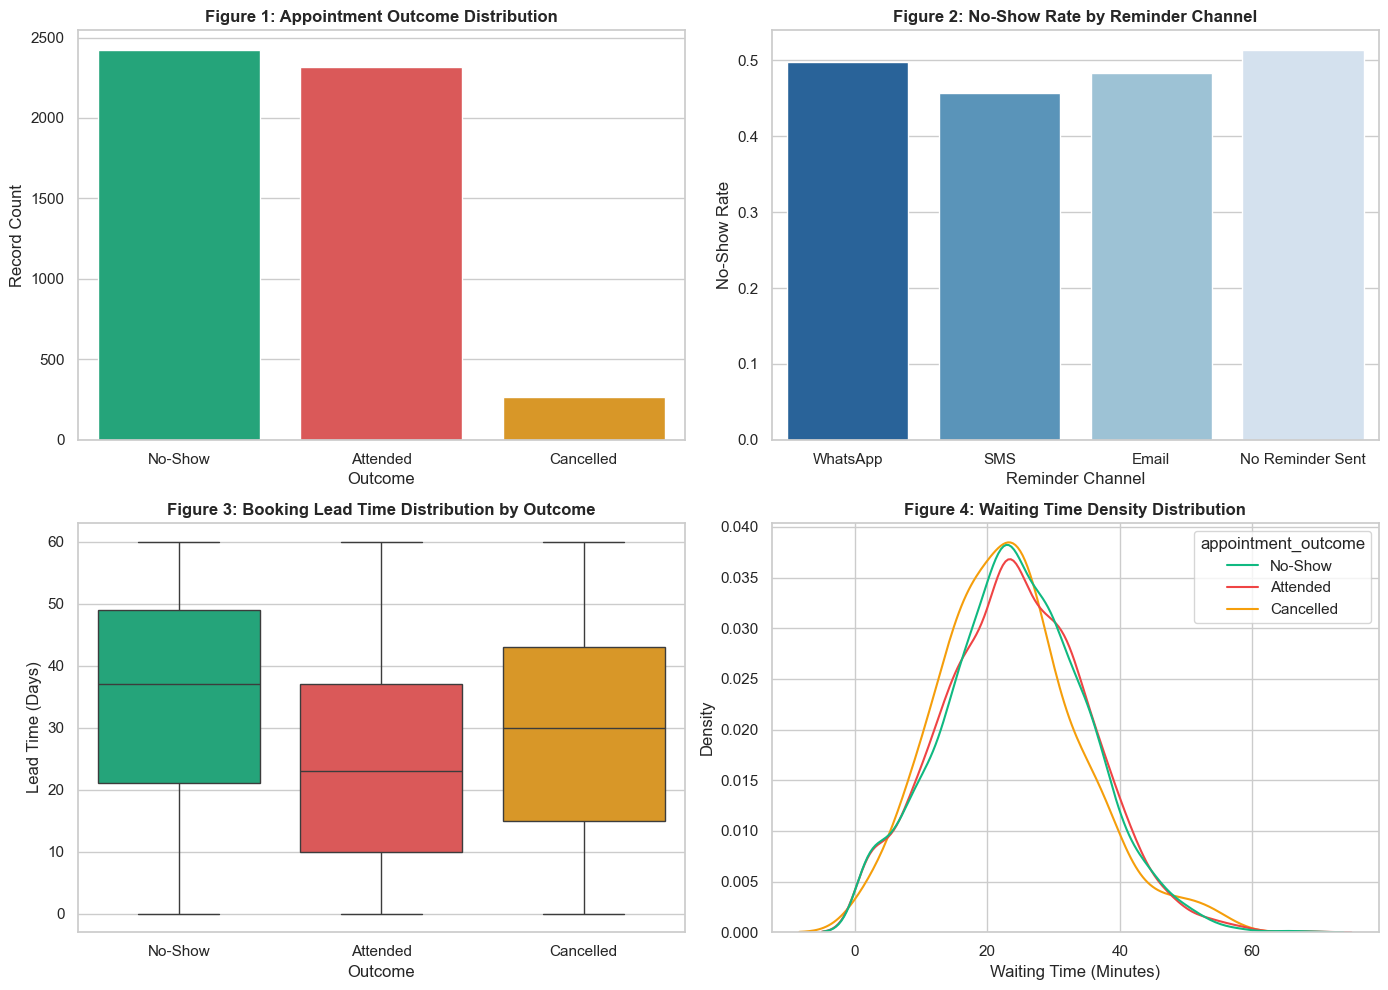

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 10, 'figure.autolayout': True})

# 1. Load Raw Dataset & Initialize DataFrame
raw_df = pd.read_csv("resources/HealthConnect_Appointment_Data.csv")
df = raw_df.copy()

# Dynamically resolve column names if slightly different in the source file
clinic_col = next((col for col in df.columns if 'clinic' in col.lower() and 'distance' not in col.lower()), 'clinic_location')
service_col = next((col for col in df.columns if 'service' in col.lower()), 'service_type')
dist_col = next((col for col in df.columns if 'distance' in col.lower()), 'distance_to_clinic_km')
wait_col = next((col for col in df.columns if 'wait' in col.lower()), 'waiting_time_minutes')

# 2. Data Preparation & Cleaning
# Subgroup median imputation for continuous missing values
if dist_col in df.columns and clinic_col in df.columns:
    df[dist_col] = df.groupby(clinic_col)[dist_col].transform(lambda x: x.fillna(x.median()))
else:
    df[dist_col] = df[dist_col].fillna(df[dist_col].median())

if wait_col in df.columns and service_col in df.columns:
    df[wait_col] = df.groupby(service_col)[wait_col].transform(lambda x: x.fillna(x.median()))
else:
    df[wait_col] = df[wait_col].fillna(df[wait_col].median())

# Explicit handling for categorical missingness
if 'reminder_channel' in df.columns:
    df['reminder_channel'] = df['reminder_channel'].fillna('No Reminder Sent')

# Datetime casting
if 'appointment_date' in df.columns:
    df['appointment_date'] = pd.to_datetime(df['appointment_date'])
if 'booking_date' in df.columns:
    df['booking_date'] = pd.to_datetime(df['booking_date'])

# Derived feature: Attendance Binary Indicator
df['is_attended'] = (df['appointment_outcome'] == 'Attended').astype(int)
df['is_noshow'] = (df['appointment_outcome'] == 'No-Show').astype(int)

# Save processed dataset separately
df.to_csv("HealthConnect_Appointment_Data_Cleaned.csv", index=False)
print("Data Preparation Complete. Cleaned file saved as 'HealthConnect_Appointment_Data_Cleaned.csv'.")

# 3. KPI Calculations
total_appts = len(df)
noshow_rate = (df['is_noshow'].sum() / total_appts) * 100

rem_sent_col = 'reminder_sent' if 'reminder_sent' in df.columns else 'reminder_channel'
if 'reminder_sent' in df.columns:
    rem_yes = df[df['reminder_sent'] == 'Yes']['is_attended'].mean() * 100
    rem_no = df[df['reminder_sent'] == 'No']['is_attended'].mean() * 100
else:
    rem_yes = df[df['reminder_channel'] != 'No Reminder Sent']['is_attended'].mean() * 100
    rem_no = df[df['reminder_channel'] == 'No Reminder Sent']['is_attended'].mean() * 100

reminder_uplift = rem_yes - rem_no

lead_col = next((col for col in df.columns if 'lead' in col.lower()), 'booking_lead_days')
lead_attended = df[df['appointment_outcome'] == 'Attended'][lead_col].mean()
lead_noshow = df[df['appointment_outcome'] == 'No-Show'][lead_col].mean()

high_wait_noshow = (df[df[wait_col] > 30]['is_noshow'].mean()) * 100

print(f"\n--- KPI CALCULATIONS ---")
print(f"KPI 1: Overall No-Show Rate: {noshow_rate:.2f}%")
print(f"KPI 2: Reminder Attendance Uplift: +{reminder_uplift:.2f}% (Sent: {rem_yes:.2f}% vs Not Sent: {rem_no:.2f}%)")
print(f"KPI 3: Avg Lead Time (Attended vs No-Show): {lead_attended:.2f} days vs {lead_noshow:.2f} days")
print(f"KPI 4: High Wait-Time (>30 min) No-Show Rate: {high_wait_noshow:.2f}%")

# 4. Generate & Save Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Viz 1: Outcome Distribution
sns.countplot(data=df, x='appointment_outcome', palette=['#10b981', '#ef4444', '#f59e0b'], ax=axes[0, 0])
axes[0, 0].set_title('Figure 1: Appointment Outcome Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Outcome')
axes[0, 0].set_ylabel('Record Count')

# Viz 2: Outcome by Reminder Channel
if 'reminder_channel' in df.columns:
    sns.barplot(data=df, x='reminder_channel', y='is_noshow', palette='Blues_r', errorbar=None, ax=axes[0, 1])
    axes[0, 1].set_title('Figure 2: No-Show Rate by Reminder Channel', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Reminder Channel')
    axes[0, 1].set_ylabel('No-Show Rate')

# Viz 3: Lead Time vs Outcome
sns.boxplot(data=df, x='appointment_outcome', y=lead_col, palette=['#10b981', '#ef4444', '#f59e0b'], ax=axes[1, 0])
axes[1, 0].set_title('Figure 3: Booking Lead Time Distribution by Outcome', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Outcome')
axes[1, 0].set_ylabel('Lead Time (Days)')

# Viz 4: Waiting Time vs Outcome
sns.kdeplot(data=df, x=wait_col, hue='appointment_outcome', common_norm=False, palette=['#10b981', '#ef4444', '#f59e0b'], ax=axes[1, 1])
axes[1, 1].set_title('Figure 4: Waiting Time Density Distribution', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Waiting Time (Minutes)')
axes[1, 1].set_ylabel('Density')

plt.tight_layout()
plt.savefig("HealthConnect_Week5_EDA_Plots.png", dpi=300)
plt.show()

In [12]:
# Save the cleaned dataframe to your local directory
df.to_csv("HealthConnect_Appointment_Data_Cleaned.csv", index=False)
print("Cleaned CSV successfully saved!")

Cleaned CSV successfully saved!
